<a href="https://colab.research.google.com/github/Brownomobola/All_things_AI/blob/main/BrownOmobola240404001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Name: Brown Omobola
### Matric Number 240404001
### Department: Mechanical Engineering

Determining my unique starting parameter $Y_o$

In [41]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

d = 4
s = 1
y_0 = d + (s/1000)
print(y_0)

4.001


### Question 1
$$\frac{dy}{dt} = y - t^{2} + 1$$

In [42]:
# Defining dy_dt
def dy_dt(y: float, t: float) -> float:
    return np.float64(y - (t**2) + 1)

# Euler's method
def euler_method(y_0: float, t: float = 0.0, h: float = 0.1, t_final: float = 2.0) -> float:
    n_iter = round((t_final - t)/h)

    y = y_0
    for _ in range(n_iter):
        y = y + (h * dy_dt(y, t))
        t += h

    return np.float64(y)

# Heun's method
def heun_method(y_0: float, t: float = 0.0, h: float = 0.1, t_final: float = 2.0) -> float:
    n_iter = round((t_final - t)/h)

    y_1 = y_0
    for _ in range(n_iter):
        k1 = dy_dt(y_1, t)
        y = y_1 + (h * k1)
        y_1 = y_1 + ((h/2) * (k1 + dy_dt(y, t+h)))
        t += h

    return np.float64(y_1)


The exact solution to the differential equation $\frac{dy}{dt} = y - t^{2} + 1$ is
$$y(t) = t^2 + 2t + 1 + 3.001e^t$$

In [43]:
# Exact solution
def exact(t: float) -> float:
    return (t**2) + 2*t + 1 + (3.001*np.exp(t))

Putting it together it becomes

In [44]:
# Euler's and Huen's for h = 0.1
euler_1 = euler_method(y_0)
heun_1 = heun_method(y_0)
ex = exact(2.0)

print(f"Euler's method wih a step size of 0.1: {euler_1:.6f}\nHeun's method with a step size of 0.1: {heun_1:.6f}\nExact solution gives: {ex:.6f}")
# Finding the absolute error of euler and huen
euler_error_1 = np.abs(euler_1 - ex)
heun_error_1 = np.abs(heun_1-ex)

print(f"Euler's absolute error: {euler_error_1:.6f}")
print(f"Huen's absolute error: {heun_error_1:.6f}")

Euler's method wih a step size of 0.1: 28.616477
Heun's method with a step size of 0.1: 31.075755
Exact solution gives: 31.174557
Euler's absolute error: 2.558080
Huen's absolute error: 0.098802


In [45]:
# Euler's and Huen's for h = 0.2
euler_2 = euler_method(y_0, h=0.2)
heun_2 = heun_method(y_0, h=0.2)

print(f"Euler's method with a step size of 0.2: {euler_2:.6f}\nHeun's method with a step size of 0.2: {heun_2:.6f}\nExact solution gives: {ex:.6f}")
# Finding the absolute error of euler and huen
euler_error_2 = np.abs(euler_2-ex)
heun_error_2 = np.abs(heun_2-ex)

print(f"Euler's method absolute error: {euler_error_2:.6f}")
print(f"Heun's method absolute error: {heun_error_2:.6f}")

Euler's method with a step size of 0.2: 26.543054
Heun's method with a step size of 0.2: 30.806569
Exact solution gives: 31.174557
Euler's method absolute error: 4.631504
Heun's method absolute error: 0.367988


To calculate the empirical order of convergence we need to use the relatioship between the absolute error at $t = 2.0$ and the step size $h$

The theoretical foundation is that the global error $E$ for a numerical method is proportional to the step size $h$ raised to the power of $p$, where $p$ is the order of convergence. This relationship is expressed as:
$$E \approx C \cdot h^p$$
Where:
- E is the final error at $t = 2.0$
- C is some constant
- h is the step size
- p is the empirial order of convergence

Using both step sizes $h = 0.1$ and $h = 0.2$ we have:
- For the larger step size: $E_{0.2} \approx C \cdot (0.1)^p$
- For the smaller step size: $E_{0.1} \approx C \cdot (0.2)^p$

Dividing both equation with each other, the constants cancels out to give:
$$\frac{E_{0.2}}{E_{0.1}} = \frac{C \cdot (0.2)^p}{C \cdot (0.1)^p} = \left(\frac{0.2}{0.1}\right)^p = 2^p$$

To isolate p we do this
$$\frac{E_{0.2}}{E_{0.1}} = 2^p$$
Taking the natural logarithm of both sides we have:
$$\ln\left(\frac{E_{0.2}}{E_{0.1}}\right) = \ln(2^p)$$
$$\ln\left(\frac{E_{0.2}}{E_{0.1}}\right) = p\cdot\ln(2)$$
$$p = \frac{\ln\left(\frac{E_{0.2}}{E_{0.1}}\right)}{\ln(2)}$$
$$p = \log_2\left(\frac{E_{0.2}}{E_{0.1}}\right)$$

In [46]:
def empirical_convergence(error_1: float, error_2: float) -> float:
    return np.log2(error_2/error_1)

In [47]:
# Finding the empirical order of convergence for Euler's method
euler_onvergence = empirical_convergence(euler_error_1, euler_error_2)

# Finding Heun's empirical order of convergence
heun_convergence = empirical_convergence(heun_error_1, heun_error_2)

print(f"The empirical order of convergence for Euler's method = {euler_onvergence:.6f}")
print(f"The empirical order of convergence for Heun's method = {heun_convergence:.6f}")

The empirical order of convergence for Euler's method = 0.856419
The empirical order of convergence for Heun's method = 1.897047


### Calculating the Local Truncation Error (LTE)
This gives us an idea of how much error is introduced moving from $y_n$ to $y_{n+1}$ assuming that we are sitting at the true solution for $y_n$. We get it by first finding the Taylor series expansion of our function. Then we find the Taylor series expansion of Euler's and Huen's method. The smallest power of our step size h left over is the local truncation error

Expanding the general function $$y(t_n + h) = y(t_n) + hy' + \frac{h^2}{2!}y'' + \frac{h^3}{3!}y''' + ...$$
### Euler
Expanding Euler's method $y_{n+1} = y(t_n + h), y_n = y(t_n) \text{ and } f(t_n, y(t_n)) = y'(t_n)$, this gives $$y_{n+1} = y(t_n) + hy'$$
Subtarcting the Euler's expansion from the general function expansion, what is left is the error of Euler $$\tau^{Euler}_{n+1} = \frac{h^2}{2!}y'' + \frac{h^3}{3!}y''' + ... \text{ which we will refer to as } O(h^2)$$
#### Heun
Expanding Huen's method
$$k_1 = f(t_n, \,y_n), \qquad \tilde{y} = y_n + hk_1, \qquad y_{n+1} = y_n + \frac{h}{2}[k_1 + \underbrace{f(t_n + h, \,\tilde{y})}_{k_2}]$$
$$k_1 = y' \text{ while } k_2 = f + hf_t + (hf)f_y + O(h^2) = f + h(f_t + f \cdot f_y) + O(h^2)$$
$$\text{Where } O(h^2) = \frac{1}{2}\left[\Delta{t^2}f_{tt} + 2\Delta{t}\Delta{y}f_{ty} + \Delta{y^2}f_yy\right]$$
$$\text{Therefore }k_2 = y' + hy'' + O(h^2)$$
Putting it back into the expansion of Heun, we have
$$y_{n+1} = y_n + \frac{h}{2}\left[y' + (y' + hy'' + O(h^2))\right] = y_n + hy' + \frac{h^2}{2}y'' + O(h^3)$$
Subtracting the expansion from the general function expansion gives us the error for Huen's $$\tau^{Heun}_{n+1} = O(h^3)$$

This makes the local truncation error for Euler $O(h^2)$ and that of Heun $O(h^3)$. This means that reducing our step size h by half reduces the per-step error in Euler by a factor 4 and the per-step error in Heun by a factor of 8. But halving $h$ also doubles the number of steps taken to cross the interval, so one power of $h$ is lost in accumulation: the global error is $O(h)$ for Euler and $O(h^2)$ for Heun. Halving the step size therefore improves the final answer by roughly 2 and 4 for Euler and Heun

### Question 2
$$\frac{dy}{dt} = -Ky -t^2 + 1$$

In [48]:
def dy_dt_damped(y: float, t: float, k: float) -> float:
    return np.float64((-1 *(k * y)) - (t**2) + 1)

def heun_method_damped(y_0: float, k: float, t: float = 0.0, h: float = 0.1, t_final: float = 2.0) -> float:
    n_iter = int((t_final - t)/h)

    y_1 = y_0
    for _ in range(n_iter):
        k1 = dy_dt_damped(y_1, t, k)
        y = y_1 + (h * k1)
        y_1 = y_1 + ((h/2) * (k1 + dy_dt_damped(y, t+h, k)))
        t += h

    return np.float64(y_1)


In [49]:
# Heun's method for the damped version
heun_damped = heun_method_damped(y_0, k=4.0, h=0.2)

The exact solution to $\frac{dy}{dt} = -Ky - t^2 + 1$ is:
$$y(t) = \frac{1 - t^2}{4} + \frac{t}{8} - \frac{1}{32} + 3.78225e^{-4t}$$

In [50]:
def exact_damped(t) -> np.ndarray:
    t = np.asarray(t, dtype=float)
    return ((1 - t**2)/4) + (t/8) - (1/32) + (3.78225*np.exp(-4 * t))

In [51]:
ex_damped = exact_damped(2.0)

print(f"The value of y using Heun's method with a step size of 0.2 = {heun_damped:.6f}")
print(f"The value of y using the exact equation = {ex_damped:.6f}")

The value of y using Heun's method with a step size of 0.2 = -0.534104
The value of y using the exact equation = -0.529981


In [52]:
# A modified heun's method for plotting the graph
def heun_damped_modified(y_0: float, k: float, t_initial: float = 0.0, h: float = 0.1, t_final: float = 2.0) -> tuple:
    n_iter = int((t_final - t_initial)/h)

    y_1 = y_0
    y_values, t_values = [y_0], [t_initial]
    for _ in range(n_iter):
        k1 = dy_dt_damped(y_1, t_initial, k)
        y = y_1 + (h * k1)
        y_1 = y_1 + ((h/2) * (k1 + dy_dt_damped(y, t_initial+h, k)))
        y_values.append(y_1)
        t_initial += h
        t_values.append(t_initial)

    return y_values, t_values

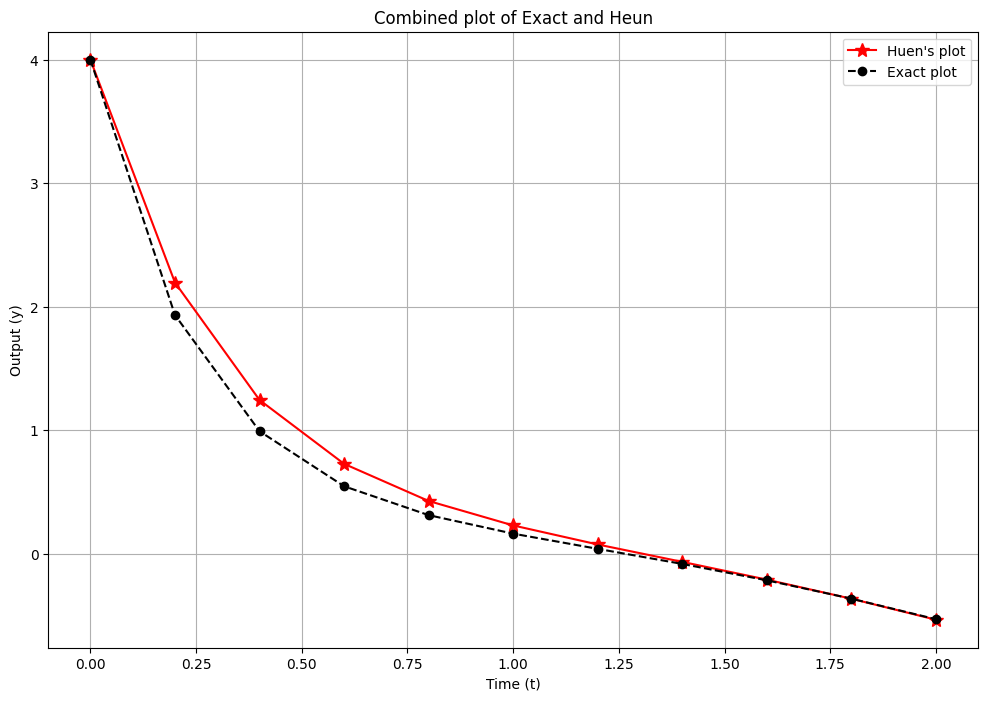

In [53]:
y_heun_damped, t_heun_damped = heun_damped_modified(y_0, k=4.0, h=0.2)

t_exact = [i * 0.2 for i in range(11)]
y_exact = exact_damped(t_exact)

plt.figure(figsize=(12, 8))
plt.plot(t_heun_damped, y_heun_damped, color='red', marker='*', ms=10, label="Huen's plot")
plt.plot(t_exact, y_exact, color="black", linestyle='--', marker='o', label="Exact plot")
plt.title("Combined plot of Exact and Heun")
plt.xlabel("Time (t)")
plt.ylabel("Output (y)")
plt.legend()
plt.grid(True)
plt.show()

### Analyzing the Numerical Stability
To know whether a step method is stable we start by linearising the the right side of our equation. Finding the partial derivative $\partial{f}/\partial{y} = -K = -4$ which is constant so the test equation is $y' = \lambda{y}$ with $\lambda = -K = -4$

Applying Heun's method to the test equation gives us $$y_{n+1} = \left(1 + z + \frac{z^2}{2}\right)y_n, \qquad z = h\lambda = -hK$$
Rewriting in terms of K $$y_{n+1} = \left(1 - 0.2K + 0.02K^2\right)$$

This makes the amplification factor $R(K) = 1 - 0.2K + 0.02K^2$. To have stability $|R(K)| \leqslant 1$, which for translates to $-2 \leq z \leq 0$ i.e $$h \leq \frac{2}{K} = 0.5 \ \text{when K = 4}$$
With $h=0.2, \ K = 4, \ R = 1 - 0.2(4) + 0.02(4^2) = 0.52$. Since $|R| \lt 1$ the entire system is stable

### The Effect of K
The global error follows the patterns $$e_{n+1} = Re_n + \tau{_n}$$ where $\tau$ is the local truncation error $O(h^3)$ which is proportional to $y'''$

The **R factor** dictates how the error propagates from one step to another. When $K = 0$ in the case of the undamped system, $R(K)$ becomes $1$. This means the error is accumulates additively and scales linearly with $t$. But when $K=4,\ R=0.52$, each step reduces the error by about half so that the errors saturates around $\tau/(1 - R)$

The **$\tau{_n}$ factor** dictates how much error is produced at each step. It is of the order of the local truncation error $O(h^3)$ $$y'''(t) = -K^3Ce^{-Kt}$$
This means K inflates the local error by a factor of $K^3$ but only when $t \lt 1$ after which it falls quickly because $y''' = 0$ and the solution is purely quadratic with little new errors been made

**Net Effect:**
- Undamped: The error is small at first and climbs linearly across the interval
- Damped: The error rises to a peak with the first two to three steps before decaying like $e^{-Kt}$